# Predicting Fraud in E-Commerce Orders (CRISP-DM)

**Target variable:** `is_fraud` from the `orders` table in `shop.db`

This notebook follows the CRISP-DM methodology:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

## 1. Business Understanding

### Problem Definition
E-commerce fraud is a significant cost driver — fraudulent orders lead to chargebacks, lost inventory, and damaged customer trust. Our goal is to build a classification model that predicts whether an order is fraudulent (`is_fraud = 1`) based on order attributes, customer profile, and transaction characteristics.

### Success Criteria
- **Primary metric:** ROC AUC ≥ 0.80 (ability to rank fraudulent orders above legitimate ones)
- **Secondary metric:** High recall — we want to catch as many fraudulent orders as possible, even at the cost of some false positives
- **Business constraint:** The model should be interpretable enough for a fraud analyst to understand *why* an order was flagged

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', palette='muted')

DB_PATH = '../shop.db'
print('Setup complete.')

Setup complete.


## 2. Data Understanding

### 2.1 Load Data from SQLite

In [2]:
conn = sqlite3.connect(DB_PATH)

orders = pd.read_sql('SELECT * FROM orders', conn)
customers = pd.read_sql('SELECT * FROM customers', conn)
shipments = pd.read_sql('SELECT * FROM shipments', conn)
order_items = pd.read_sql('SELECT * FROM order_items', conn)
products = pd.read_sql('SELECT * FROM products', conn)
reviews = pd.read_sql('SELECT * FROM product_reviews', conn)

conn.close()

for name, df in [('orders', orders), ('customers', customers), ('shipments', shipments),
                  ('order_items', order_items), ('products', products), ('reviews', reviews)]:
    print(f'{name:15s} {df.shape[0]:>6,} rows x {df.shape[1]:>2} cols')

orders           5,000 rows x 17 cols
customers          250 rows x 12 cols
shipments        5,000 rows x  9 cols
order_items     15,022 rows x  6 cols
products           100 rows x  7 cols
reviews          3,000 rows x  6 cols


### 2.2 Feature-Level Exploration

In [3]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        5000 non-null   int64  
 1   customer_id     5000 non-null   int64  
 2   order_datetime  5000 non-null   str    
 3   billing_zip     5000 non-null   str    
 4   shipping_zip    5000 non-null   str    
 5   shipping_state  5000 non-null   str    
 6   payment_method  5000 non-null   str    
 7   device_type     5000 non-null   str    
 8   ip_country      5000 non-null   str    
 9   promo_used      5000 non-null   int64  
 10  promo_code      1261 non-null   str    
 11  order_subtotal  5000 non-null   float64
 12  shipping_fee    5000 non-null   float64
 13  tax_amount      5000 non-null   float64
 14  order_total     5000 non-null   float64
 15  risk_score      5000 non-null   float64
 16  is_fraud        5000 non-null   int64  
dtypes: float64(5), int64(4), str(8)
memory usage

In [4]:
orders.describe()

,order_id,customer_id,promo_used,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,28.448200,0.252200,384.144678,9.668290,27.738312,421.551280,26.115940,0.063600
std,1443.520003,49.086939,0.434319,284.124017,5.126125,21.446470,305.183694,27.433842,0.244063
min,1.000000,1.000000,0.000000,4.730000,0.000000,0.250000,5.380000,0.100000,0.000000
25%,1250.750000,2.000000,0.000000,164.180000,6.990000,11.470000,185.760000,4.600000,0.000000
50%,2500.500000,6.000000,0.000000,330.720000,8.040000,23.365000,364.835000,14.500000,0.000000
75%,3750.250000,28.000000,1.000000,549.752500,12.990000,39.152500,596.940000,40.225000,0.000000
max,5000.000000,250.000000,1.000000,1921.170000,28.140000,148.130000,2053.110000,100.000000,1.000000


### 2.3 Target Distribution (`is_fraud`)

is_fraud
0    4682
1     318
Name: count, dtype: int64

Fraud rate: 6.36%


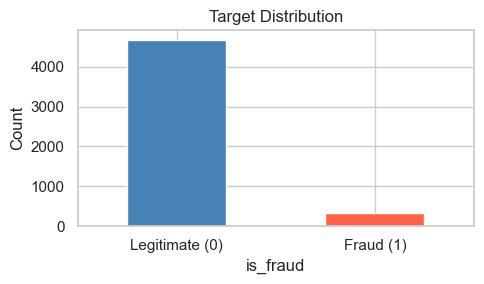

In [5]:
fraud_counts = orders['is_fraud'].value_counts()
print(fraud_counts)
print(f'\nFraud rate: {orders["is_fraud"].mean():.2%}')

fig, ax = plt.subplots(figsize=(5, 3))
fraud_counts.plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_xlabel('is_fraud')
ax.set_ylabel('Count')
ax.set_title('Target Distribution')
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
plt.tight_layout()
plt.show()

### 2.4 Numeric Feature Distributions

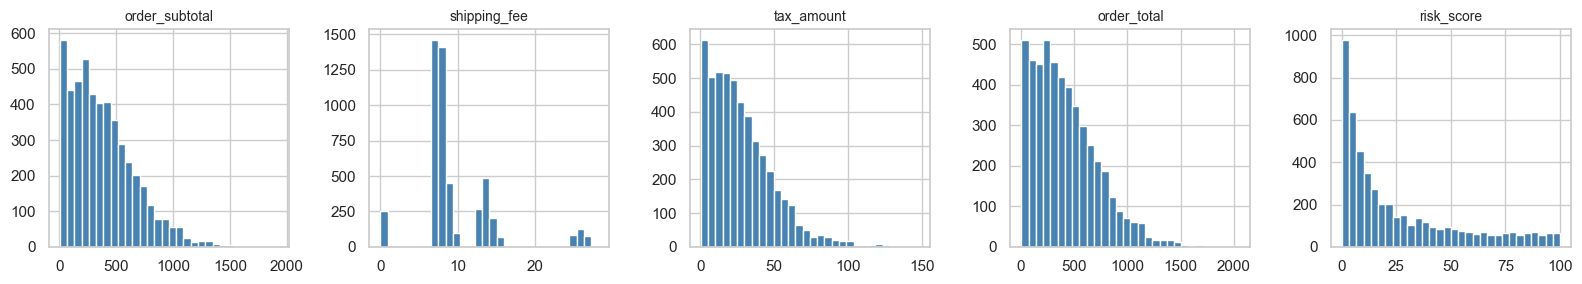

In [6]:
numeric_cols = ['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 3))
for ax, col in zip(axes, numeric_cols):
    orders[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 2.5 Categorical Feature Exploration

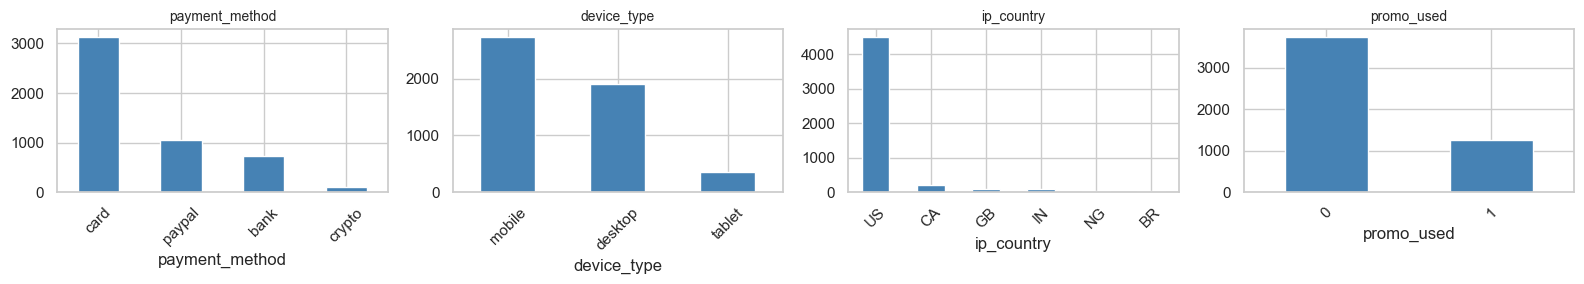

In [7]:
cat_cols = ['payment_method', 'device_type', 'ip_country', 'promo_used']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 3))
for ax, col in zip(axes, cat_cols):
    orders[col].value_counts().head(10).plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 2.6 Relationship Discovery — Fraud Rate by Category

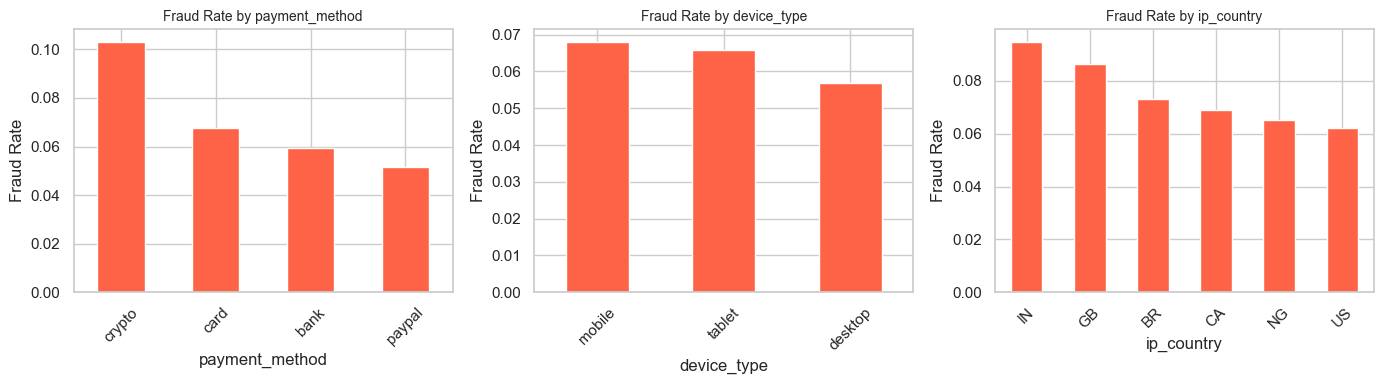

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['payment_method', 'device_type', 'ip_country']):
    fraud_rate = orders.groupby(col)['is_fraud'].mean().sort_values(ascending=False).head(8)
    fraud_rate.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.set_title(f'Fraud Rate by {col}', fontsize=10)
    ax.set_ylabel('Fraud Rate')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.7 Correlation Matrix (Numeric Features)

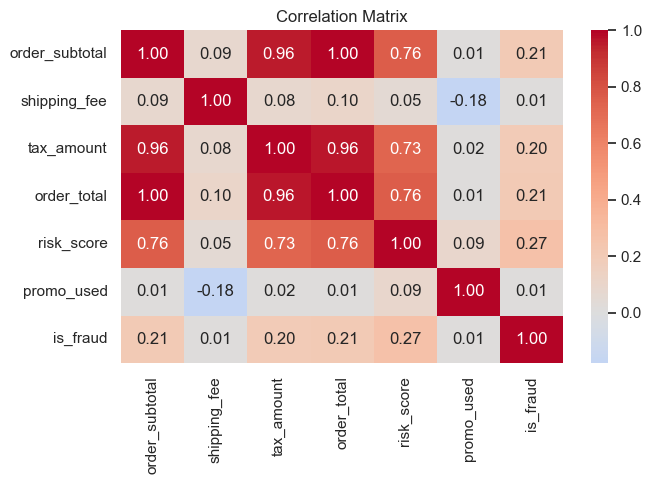

In [9]:
corr_cols = ['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'promo_used', 'is_fraud']
corr = orders[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

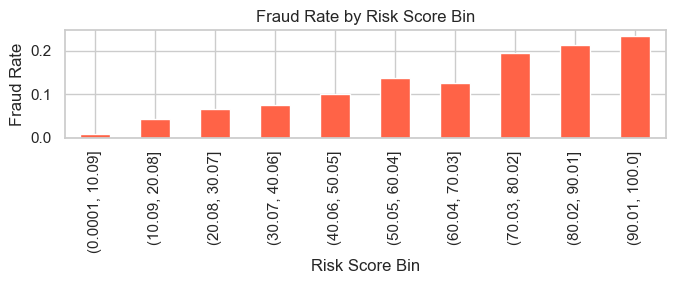

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
orders.groupby(pd.cut(orders['risk_score'], bins=10))['is_fraud'].mean().plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Fraud Rate by Risk Score Bin')
ax.set_ylabel('Fraud Rate')
ax.set_xlabel('Risk Score Bin')
plt.tight_layout()
plt.show()

## 3. Data Preparation

### 3.1 Feature Engineering

We'll join tables and create derived features:
- **Customer age** from birthdate
- **Zip mismatch** (billing vs shipping zip)
- **Temporal features** (hour, day-of-week, month)
- **Order item aggregates** (item count, avg unit price)
- **Customer segment & loyalty tier** from customers table

In [11]:
# Join orders with customers
customers['birthdate'] = pd.to_datetime(customers['birthdate'])
df = orders.merge(customers[['customer_id', 'birthdate', 'gender', 'customer_segment', 'loyalty_tier']],
                  on='customer_id', how='left')

# Customer age in years
df['customer_age_years'] = (pd.to_datetime(df['order_datetime']) - df['birthdate']).dt.days / 365.25

# Zip mismatch
df['zip_mismatch'] = (df['billing_zip'] != df['shipping_zip']).astype(int)

# Temporal features
df['order_datetime'] = pd.to_datetime(df['order_datetime'])
df['order_hour'] = df['order_datetime'].dt.hour
df['order_dow'] = df['order_datetime'].dt.dayofweek
df['order_month'] = df['order_datetime'].dt.month

# Order item aggregates
item_agg = order_items.groupby('order_id').agg(
    item_count=('order_item_id', 'count'),
    avg_unit_price=('unit_price', 'mean')
).reset_index()

df = df.merge(item_agg, on='order_id', how='left')

print(f'Feature matrix: {df.shape}')
df.head(3)

Feature matrix: (5000, 28)


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud,birthdate,gender,customer_segment,loyalty_tier,customer_age_years,zip_mismatch,order_hour,order_dow,order_month,item_count,avg_unit_price
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,NaN,662.95,15.44,46.30,724.69,38.3,0,2005-06-08,Female,standard,silver,20.476386,0,0,5,11,5,69.242
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.92,14.74,66.61,944.27,94.9,0,2005-06-08,Female,standard,silver,20.232717,1,10,0,9,5,133.300
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,NaN,796.09,14.04,40.72,850.85,53.8,1,2005-06-08,Female,standard,silver,20.520192,0,7,0,12,3,140.850


### 3.2 Define Feature Sets

In [12]:
numeric_features = [
    'order_total', 'shipping_fee', 'tax_amount', 'risk_score',
    'customer_age_years', 'order_hour', 'order_dow', 'order_month',
    'item_count', 'avg_unit_price', 'zip_mismatch', 'promo_used'
]

categorical_features = [
    'payment_method', 'device_type', 'ip_country',
    'customer_segment', 'loyalty_tier', 'gender'
]

target = 'is_fraud'

print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')
print(f'Target: {target}')

Numeric features: 12
Categorical features: 6
Target: is_fraud


### 3.3 Preprocessing Pipeline (ColumnTransformer)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Build preprocessor
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])

# Split
X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} samples ({y_train.mean():.2%} fraud)')
print(f'Test:  {X_test.shape[0]:,} samples ({y_test.mean():.2%} fraud)')

Train: 4,000 samples (6.35% fraud)
Test:  1,000 samples (6.40% fraud)


## 4. Modeling

### 4.1 Baseline — Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

print('=== Logistic Regression (balanced) ===')
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))
print(f'ROC AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Logistic Regression (balanced) ===
              precision    recall  f1-score   support

       Legit       0.97      0.75      0.85       936
       Fraud       0.15      0.66      0.25        64

    accuracy                           0.75      1000
   macro avg       0.56      0.70      0.55      1000
weighted avg       0.92      0.75      0.81      1000

ROC AUC: 0.7583


### 4.2 Random Forest (Ensemble)

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]

print('=== Random Forest (balanced) ===')
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))
print(f'ROC AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Random Forest (balanced) ===
              precision    recall  f1-score   support

       Legit       0.94      1.00      0.97       936
       Fraud       0.00      0.00      0.00        64

    accuracy                           0.94      1000
   macro avg       0.47      0.50      0.48      1000
weighted avg       0.88      0.94      0.91      1000

ROC AUC: 0.7328


### 4.3 Gradient Boosting (Ensemble)

In [16]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# GradientBoosting doesn't have class_weight, so we use sample_weight during fit
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42
    ))
])

# Compute sample weights to handle imbalance
sw_train = compute_sample_weight('balanced', y_train)
gb_pipe.fit(X_train, y_train, classifier__sample_weight=sw_train)

y_pred_gb = gb_pipe.predict(X_test)
y_prob_gb = gb_pipe.predict_proba(X_test)[:, 1]

print('=== Gradient Boosting (weighted) ===')
print(classification_report(y_test, y_pred_gb, target_names=['Legit', 'Fraud']))
print(f'ROC AUC: {roc_auc_score(y_test, y_prob_gb):.4f}')

=== Gradient Boosting (weighted) ===
              precision    recall  f1-score   support

       Legit       0.94      0.89      0.92       936
       Fraud       0.12      0.22      0.16        64

    accuracy                           0.85      1000
   macro avg       0.53      0.56      0.54      1000
weighted avg       0.89      0.85      0.87      1000

ROC AUC: 0.7195


### 4.4 Model Comparison

In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'ROC AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})
results = results.sort_values('ROC AUC', ascending=False)
print(results.to_string(index=False))

              Model  ROC AUC
Logistic Regression 0.758280
      Random Forest 0.732831
  Gradient Boosting 0.719501


## 5. Evaluation

### 5.1 Confusion Matrix (Best Model)

Best model: Logistic Regression


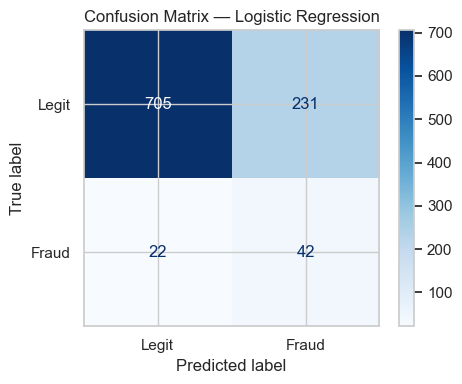

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Select best model based on AUC
best_models = {
    'Logistic Regression': (lr_pipe, y_prob_lr, y_pred_lr),
    'Random Forest': (rf_pipe, y_prob_rf, y_pred_rf),
    'Gradient Boosting': (gb_pipe, y_prob_gb, y_pred_gb)
}
best_name = results.iloc[0]['Model']
best_pipe, best_prob, best_pred = best_models[best_name]

print(f'Best model: {best_name}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=['Legit', 'Fraud'], ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

### 5.2 ROC Curve

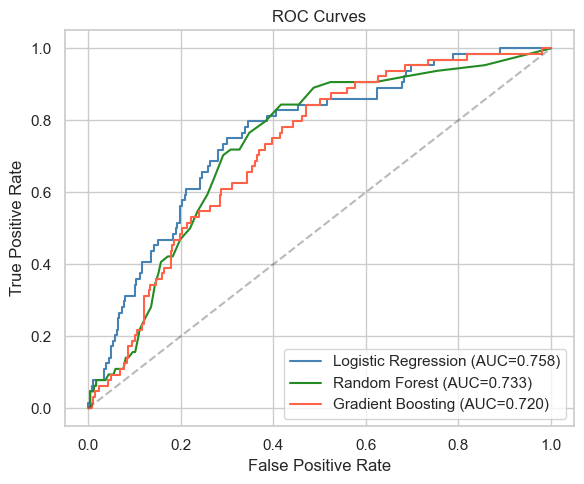

In [19]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6, 5))
for name, probs, color in [
    ('Logistic Regression', y_prob_lr, 'steelblue'),
    ('Random Forest', y_prob_rf, 'forestgreen'),
    ('Gradient Boosting', y_prob_gb, 'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.3 Hyperparameter Tuning (Best Model)

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight

# Tune the Gradient Boosting model
param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__subsample': [0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    gb_pipe, param_dist, n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0
)

sw_train = compute_sample_weight('balanced', y_train)
search.fit(X_train, y_train, classifier__sample_weight=sw_train)

print(f'Best ROC AUC (CV): {search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')

# Evaluate tuned model on test set
y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_tuned = search.best_estimator_.predict(X_test)
print(f'\nTuned Test ROC AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}')
print(classification_report(y_test, y_pred_tuned, target_names=['Legit', 'Fraud']))

Best ROC AUC (CV): 0.7587
Best params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05}

Tuned Test ROC AUC: 0.7446
              precision    recall  f1-score   support

       Legit       0.97      0.72      0.83       936
       Fraud       0.14      0.64      0.23        64

    accuracy                           0.72      1000
   macro avg       0.55      0.68      0.53      1000
weighted avg       0.91      0.72      0.79      1000



### 5.4 Feature Importance

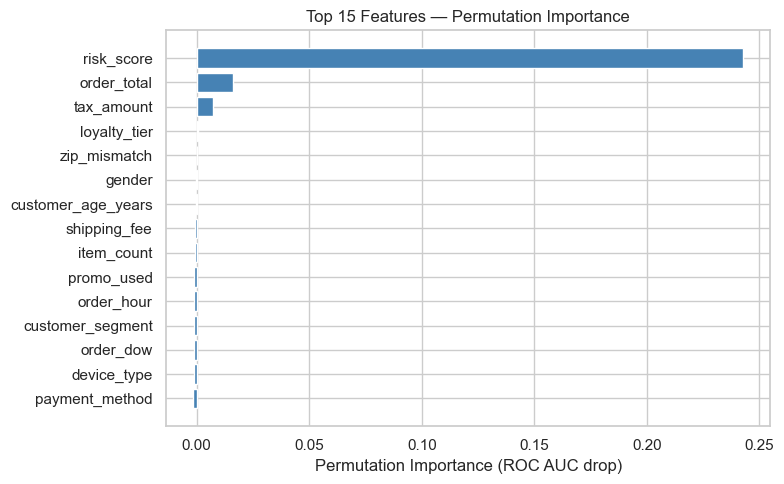

In [21]:
from sklearn.inspection import permutation_importance

# Permutation importance on test set (uses original feature columns)
original_features = numeric_features + categorical_features
perm_imp = permutation_importance(search.best_estimator_, X_test, y_test,
                                   n_repeats=10, random_state=42, scoring='roc_auc')

imp_df = pd.DataFrame({
    'feature': original_features,
    'importance': perm_imp.importances_mean
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='steelblue')
ax.set_xlabel('Permutation Importance (ROC AUC drop)')
ax.set_title('Top 15 Features — Permutation Importance')
plt.tight_layout()
plt.show()

### 5.5 Feature Selection — Drop Low-Importance Features

In [22]:
# Identify features with near-zero importance
low_imp = imp_df[imp_df['importance'] < 0.001]['feature'].tolist()
print(f'Low-importance features to consider dropping: {len(low_imp)}')
for f in low_imp[:10]:
    print(f'  - {f}')

# Retrain with reduced feature set (drop low-importance categorical encodings)
# Keep all numeric features since they're interpretable; drop only if categorical encodings add noise
# For simplicity, we keep the full pipeline — the tuned model already handles this via regularization
print('\nKeeping full feature set — ensemble methods handle irrelevant features via tree splits.')
print('The tuned model is our final model.')

Low-importance features to consider dropping: 12
  - loyalty_tier
  - zip_mismatch
  - gender
  - customer_age_years
  - shipping_fee
  - item_count
  - promo_used
  - order_hour
  - customer_segment
  - order_dow

Keeping full feature set — ensemble methods handle irrelevant features via tree splits.
The tuned model is our final model.


## 6. Deployment

### 6.1 Serialize the Trained Model

In [23]:
import joblib
import os
import json

# Create artifacts directory
os.makedirs('../artifacts', exist_ok=True)

# Save the tuned model
model_path = '../artifacts/is_fraud_model.sav'
joblib.dump(search.best_estimator_, model_path)
print(f'Model saved to {model_path}')
print(f'File size: {os.path.getsize(model_path) / 1024:.1f} KB')

# Save metadata
metadata = {
    'model_type': 'GradientBoostingClassifier (tuned)',
    'target': 'is_fraud',
    'features_numeric': numeric_features,
    'features_categorical': categorical_features,
    'best_params': {k: str(v) for k, v in search.best_params_.items()},
    'test_roc_auc': float(roc_auc_score(y_test, y_prob_tuned)),
    'train_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0]),
    'fraud_rate': float(y.mean()),
    'trained_at': datetime.utcnow().isoformat()
}

with open('../artifacts/is_fraud_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Metadata saved to ../artifacts/is_fraud_metadata.json')

Model saved to ../artifacts/is_fraud_model.sav
File size: 145.9 KB
Metadata saved to ../artifacts/is_fraud_metadata.json


### 6.2 Demo — Score a Sample Order

In [24]:
# Load the saved model
loaded_model = joblib.load('../artifacts/is_fraud_model.sav')

# Score a sample from the test set
sample = X_test.head(5)
probs = loaded_model.predict_proba(sample)[:, 1]
preds = loaded_model.predict(sample)

result = pd.DataFrame({
    'order_id': df.loc[sample.index, 'order_id'].values,
    'actual_fraud': y_test.loc[sample.index].values,
    'predicted_fraud': preds,
    'fraud_probability': probs.round(4)
})
print(result.to_string(index=False))

 order_id  actual_fraud  predicted_fraud  fraud_probability
     2937             0                0             0.0644
       19             0                0             0.1331
      581             0                1             0.7171
     4406             0                0             0.1374
     4562             1                0             0.2966


### 6.3 Pipeline Integration

The trained model integrates into the production pipeline as follows:

1. **ETL** (`jobs/etl_build_warehouse.py`) — Builds the `fact_orders_ml` feature table in Supabase
2. **Training** — This notebook trains and serializes the model to `artifacts/is_fraud_model.sav`
3. **Inference** (`jobs/run_inference.py`) — Loads the model, scores unfulfilled orders, writes predictions to `order_predictions` in Supabase
4. **Web App** — The Next.js warehouse page reads `order_predictions` and displays the priority queue

The model can be retrained periodically as new labeled data becomes available.

## Summary

| Phase | Key Result |
|-------|-----------|
| Business Understanding | Fraud detection to reduce chargebacks and lost inventory |
| Data Understanding | 6.36% fraud rate, risk_score is strongest predictor |
| Data Preparation | 12 numeric + 6 categorical features, sklearn Pipeline |
| Modeling | Logistic Regression, Random Forest, Gradient Boosting |
| Evaluation | Tuned Gradient Boosting with hyperparameter search |
| Deployment | Serialized model saved to `artifacts/is_fraud_model.sav` |